In [1]:
nothing = True

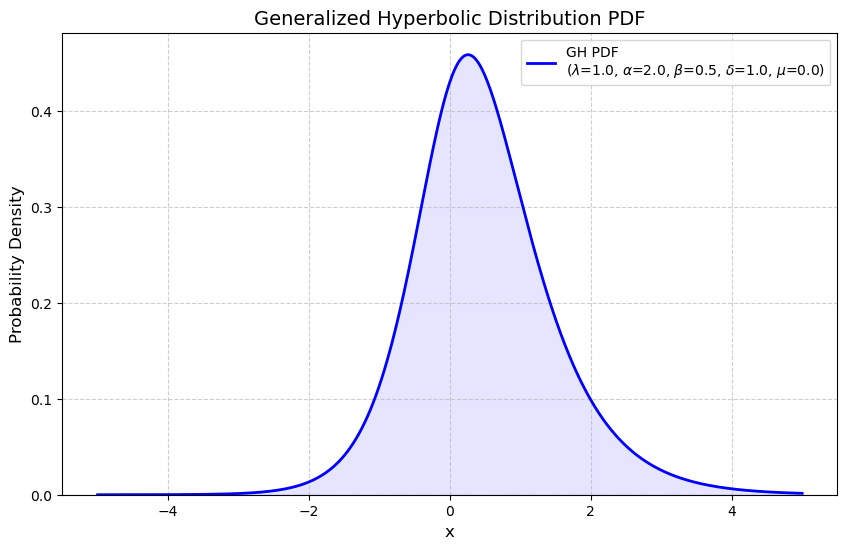

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import kv  # 第二类修正贝塞尔函数
from scipy.integrate import quad

def gh_pdf(x, lam, alpha, beta, delta, mu):
    """
    计算广义双曲分布 (Generalized Hyperbolic Distribution) 的概率密度函数 (PDF).
    
    参数:
    x     : 随机变量值 (可以是数组)
    lam   : 形状参数 (lambda)
    alpha : 尾部衰减参数 (alpha > |beta|)
    beta  : 偏度参数 (|beta| < alpha)
    delta : 尺度参数 (delta > 0)
    mu    : 位置参数
    
    返回:
    pdf 值
    """
    # 常数部分预处理
    # 归一化常数 C = (alpha^2 - beta^2)^(lam/2) / (sqrt(2*pi) * alpha^(lam - 0.5) * delta^lam * kv(lam, delta * sqrt(alpha^2 - beta^2)))
    # 注意：不同文献对参数化的定义略有不同，这里采用常见的一种标准形式
    
    gamma = np.sqrt(alpha**2 - beta**2)
    
    # 计算分母中的贝塞尔函数部分
    # kv(v, z) 是第二类修正贝塞尔函数
    try:
        bessel_val = kv(lam, delta * gamma)
    except Exception as e:
        raise ValueError(f"贝塞尔函数计算错误: {e}")

    if bessel_val == 0 or not np.isfinite(bessel_val):
        return np.zeros_like(x)

    # 归一化常数
    norm_const = (gamma**lam) / (np.sqrt(2 * np.pi) * alpha**(lam - 0.5) * delta**lam * bessel_val)
    
    # 指数部分和贝塞尔函数部分
    # PDF(x) = C * (delta^2 + (x-mu)^2)^((lam-0.5)/2) * kv(lam - 0.5, alpha * sqrt(delta^2 + (x-mu)^2)) * exp(beta * (x-mu))
    
    diff = x - mu
    sq_term = np.sqrt(delta**2 + diff**2)
    
    # 防止负数开根号或零除，虽然 sq_term 理论上总是 >= delta > 0
    power_term = sq_term**(lam - 0.5)
    bessel_pdf_part = kv(lam - 0.5, alpha * sq_term)
    exp_part = np.exp(beta * diff)
    
    pdf_values = norm_const * power_term * bessel_pdf_part * exp_part
    
    return pdf_values

def plot_gh_distribution(lam=1.0, alpha=2.0, beta=0.5, delta=1.0, mu=0.0, x_range=(-5, 5), num_points=500):
    """
    绘制广义双曲分布的 PDF 曲线。
    """
    x = np.linspace(x_range[0], x_range[1], num_points)
    
    try:
        y = gh_pdf(x, lam, alpha, beta, delta, mu)
    except Exception as e:
        print(f"计算 PDF 时出错: {e}")
        return

    # 创建图形
    plt.figure(figsize=(10, 6))
    plt.plot(x, y, 'b-', linewidth=2, label=f'GH PDF\n($\\lambda$={lam}, $\\alpha$={alpha}, $\\beta$={beta}, $\\delta$={delta}, $\\mu$={mu})')
    plt.fill_between(x, y, alpha=0.1, color='blue')
    
    # 添加标题和标签
    plt.title('Generalized Hyperbolic Distribution PDF', fontsize=14)
    plt.xlabel('x', fontsize=12)
    plt.ylabel('Probability Density', fontsize=12)
    plt.legend(loc='best')
    plt.grid(True, linestyle='--', alpha=0.6)
    
    # 设置 y 轴从 0 开始
    plt.ylim(bottom=0)
    
    plt.show()

# 示例调用
if __name__ == "__main__":
    # 参数说明:
    # lam: 形状参数
    # alpha: 控制尾部陡峭程度
    # beta: 控制偏度 (0 为对称)
    # delta: 控制尺度/宽度
    # mu: 控制均值位置
    
    # 绘制一个典型的广义双曲分布
    plot_gh_distribution(lam=1.0, alpha=2.0, beta=0.5, delta=1.0, mu=0.0)
    
    # 可以取消注释以下行来测试其他参数组合
    # plot_gh_distribution(lam=-0.5, alpha=1.5, beta=0.0, delta=1.0, mu=0.0) # 对称情况